In [1]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M').astype(str)
sns.set_theme(style='whitegrid')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10


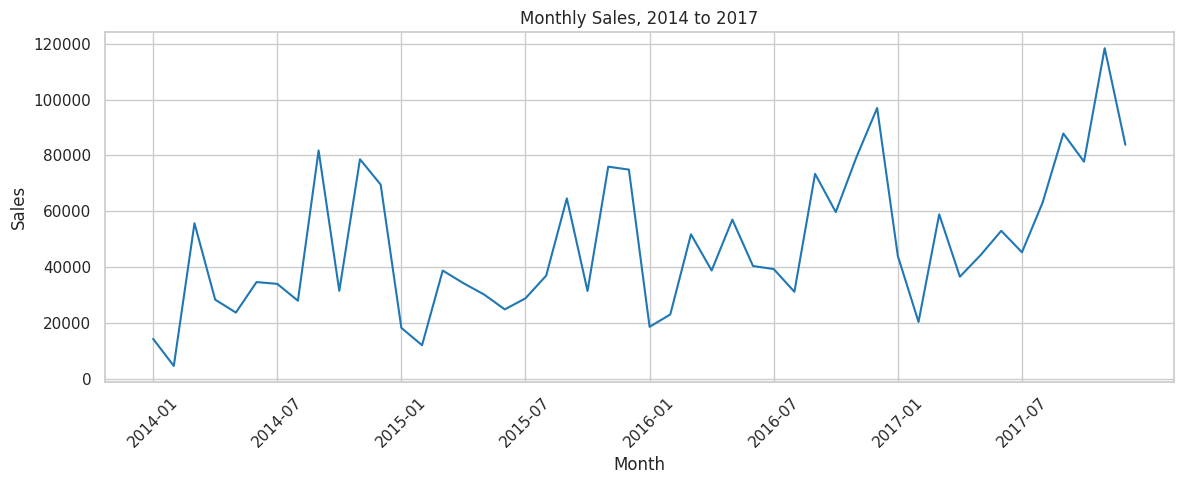

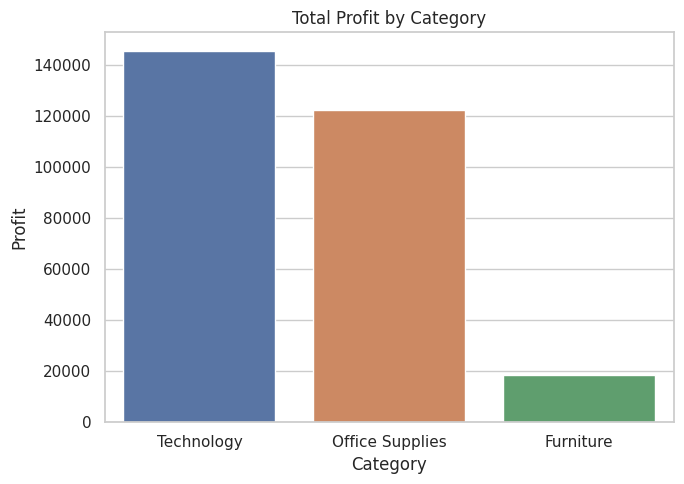

In [3]:
# Chart 1: Monthly sales
monthly = df.groupby('Month')['Sales'].sum()
plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly.values, color='#1f77b4')
plt.xticks(range(0, len(monthly), 6), monthly.index[::6], rotation=45)
plt.title('Monthly Sales, 2014 to 2017')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

# Chart 2: Profit by category
cat = df.groupby('Category')['Profit'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(7, 5))
sns.barplot(data=cat, x='Category', y='Profit', hue='Category', legend=False)
plt.title('Total Profit by Category')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

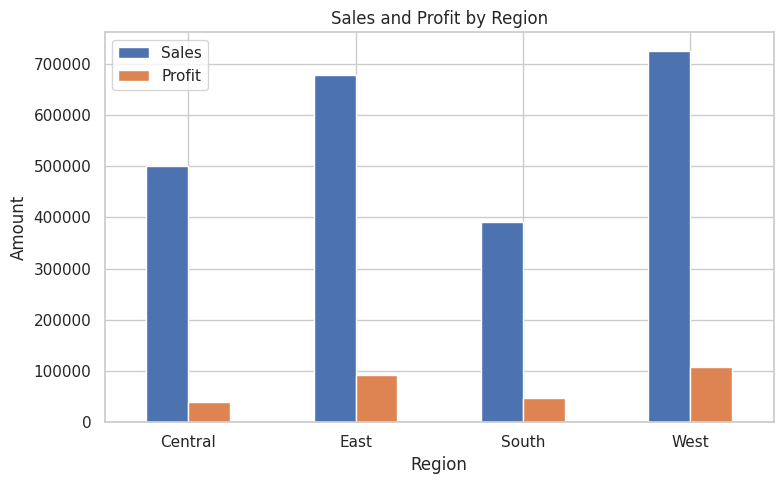

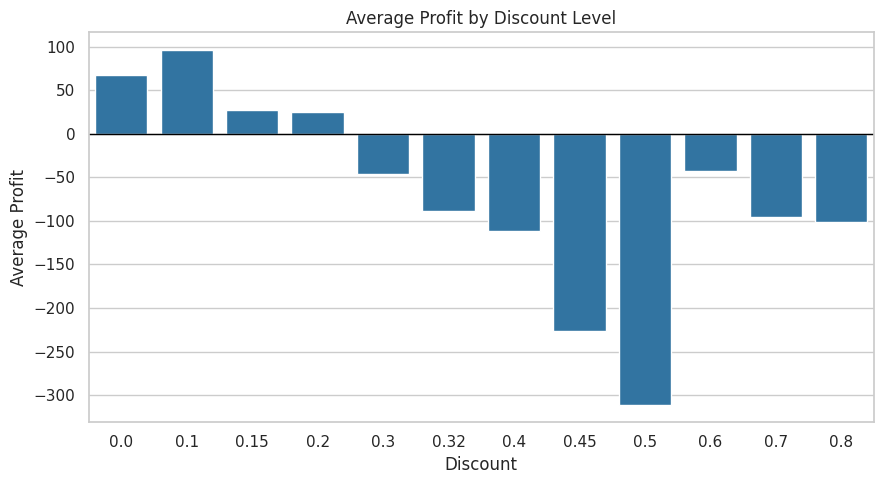

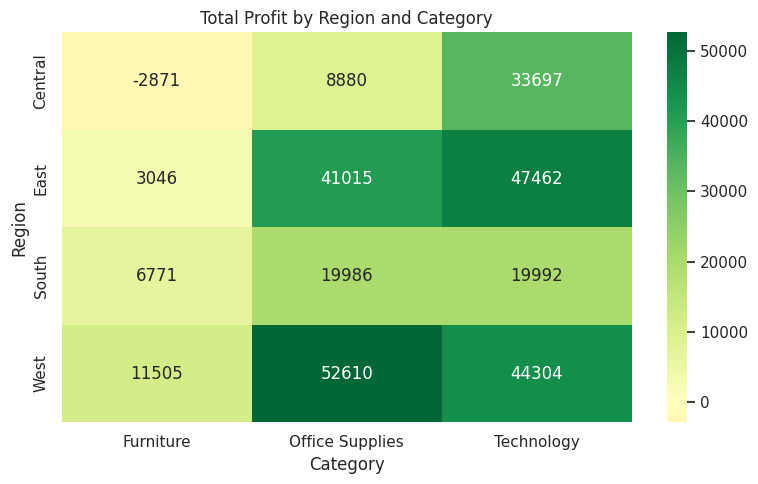

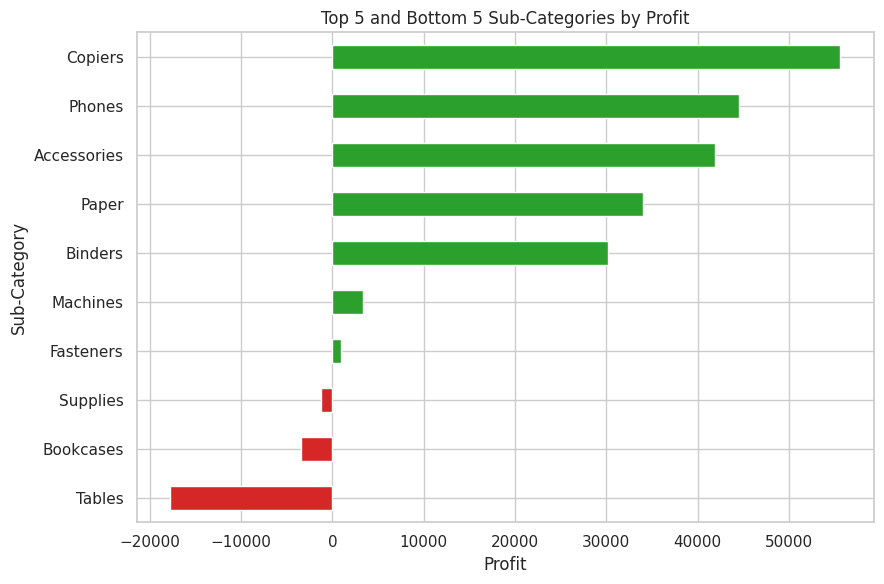

In [4]:
# Chart 3: Sales and profit by region
reg = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()
reg.plot(x='Region', kind='bar', figsize=(8, 5), rot=0)
plt.title('Sales and Profit by Region')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

# Chart 4: Average profit by discount level
disc = df.groupby('Discount')['Profit'].mean().reset_index()
plt.figure(figsize=(9, 5))
sns.barplot(data=disc, x='Discount', y='Profit', color='#1f77b4')
plt.axhline(0, color='black', linewidth=1)
plt.title('Average Profit by Discount Level')
plt.ylabel('Average Profit')
plt.tight_layout()
plt.show()

# Chart 5: Profit heatmap, region by category
pivot = df.pivot_table(values='Profit', index='Region',
                       columns='Category', aggfunc='sum')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Total Profit by Region and Category')
plt.tight_layout()
plt.show()

# Chart 6: Best and worst sub-categories
sub = df.groupby('Sub-Category')['Profit'].sum().sort_values()
tb = pd.concat([sub.head(5), sub.tail(5)])
colors = ['#d62728' if v < 0 else '#2ca02c' for v in tb.values]
plt.figure(figsize=(9, 6))
tb.plot(kind='barh', color=colors)
plt.title('Top 5 and Bottom 5 Sub-Categories by Profit')
plt.xlabel('Profit')
plt.tight_layout()
plt.show()

## Key Insights

**Chart 1: Monthly sales.** Sales grew about 51% from 2014 to 2017. Every year peaks between September and December, and the highest month is November 2017 at roughly 118,000.

**Chart 2: Profit by category.** Technology earns the most profit (145,455) and Office Supplies is second (122,491). Furniture earns only 18,451 despite strong sales.

**Chart 3: Region.** West leads in both sales (725,458) and profit (108,418). Central makes only 39,706 profit on 501,240 in sales, the weakest margin of the four regions.

**Chart 4: Discounts.** Orders discounted up to 20% make money on average. From 30% upward the average order loses money, and the loss is largest at 50% (about -311 per order).
**Chart 5: Region and category heatmap.** The biggest profit sources are West Office Supplies (52,610) and East Technology (47,462). Central Furniture is the only loss-making combination, at -2,871. Furniture is weak in every region, with its best result at only 11,505 in the West.

**Chart 6: Sub-categories.** Copiers are the most profitable sub-category (about 55,000), followed by Phones, Accessories, Paper, and Binders. Tables lose the most money (about -18,000), followed by Bookcases and Supplies. Tables and Bookcases are both Furniture, which explains the category's low profit.